Red = lipid droplets · Yellow = mutant LC3 · Green = normal LC3 · Blue = mitochondria

Segment whole cells from the yellow+green composite, then classify green-positive cells. For LC3 structures, count each dot/ring separately; fill hollow rings before overlap tests so an encased red or blue object still counts as a match. MFI is measured on raw channels only.


## Imports
Download all dependencies prior to running

In [1]:
%matplotlib inline
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

import czifile
from scipy import ndimage as ndi
from skimage import exposure, morphology
from skimage.color import label2rgb
from skimage.filters import threshold_otsu, gaussian
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects, disk, binary_dilation, closing
from skimage.segmentation import relabel_sequential, watershed

## 2 · Parameters & segmentation method

In [2]:
BASE_DIR = "."
# One or more folders holding the .czi images (resolved under BASE_DIR then images/).
IMAGE_FOLDER_NAMES = [
    "L3 Lipophagy images",
]


def resolve_image_folder(name):
    """Return the first existing path for `name` (under BASE_DIR, then images/),
    else the BASE_DIR path (which will simply be skipped if it never appears)."""
    for cand in (os.path.join(BASE_DIR, name), os.path.join(BASE_DIR, "images", name)):
        if os.path.isdir(cand):
            return cand
    return os.path.join(BASE_DIR, name)


IMAGE_FOLDERS = [resolve_image_folder(n) for n in IMAGE_FOLDER_NAMES]

FILE_EXTENSION = "*.czi"
RESULTS_FOLDER = "Results"
MASK_FOLDER = os.path.join(RESULTS_FOLDER, "masks")
CSV_SUFFIX = "LC3_lipophagy_mitophagy_analysis.csv"  # final CSV = "<folder>_<CSV_SUFFIX>"
SHOW_PLOTS = True  # set False to skip the QC panels on long batch runs

# CHANNEL MAPPING -> red, yellow, green, blue
#   idx0 AF633 far-red  -> LipidTOX  -> lipid droplets   (red)
#   idx1 AF555          -> mutant LC3                     (yellow)
#   idx2 AF488          -> normal LC3-GFP                 (green)
#   idx3 BFP            -> mitochondria                   (blue)
CHANNEL_ORDER = {"red": 0, "yellow": 1, "green": 2, "blue": 3}

USE_CELLPOSE = True
USE_GPU = True

# CELL SEGMENTATION — Cellpose cyto3 on the YELLOW + GREEN composite.
# No nucleus channel exists; both LC3 markers fill the whole cytoplasm, so their
# composite is the cleanest whole-cell silhouette. Blue (mito) is NOT used — it is
# streaky and would fragment the cell body. The composite is Gaussian-smoothed
# before Cellpose because the diffuse, highly-textured cells otherwise confuse the
# flow field (Cellpose then mislabels background as a "cell").
CYTO_SEG_CHANNELS = ["yellow", "green"]
CYTO_SMOOTH_SIGMA = 3.0      # blur the composite before Cellpose to suppress texture
CYTO_DIAMETER = 250          # cell diameter in px — these M17D cells are large
CYTO_FLOW_THRESH = 0.9       # higher = more lenient (accepts more cells)
CYTO_PROB_THRESH = -1.0      # lower = more lenient (catches dimmer cells)
CELL_MIN_AREA = 3000         # drop objects smaller than a real cell
CELL_MIN_MEAN_SIGNAL = 0.12  # drop labels whose mean composite is background-dim

# GREEN-POSITIVE CELL — a cell is "green" (expresses normal LC3) when it is almost
# completely filled with green signal.
GREEN_FILL_SIGMA = 2.0
GREEN_FILL_THRESH = 0.08  # green (percentile-norm) above this counts as 'green present'
GREEN_FILL_FRAC = 0.40    # cell is green-positive if >= this fraction is green-filled

# NORMAL-LC3 STRUCTURES (green dots + rings) — cell-aware puncta detection.
# White top-hat isolates bright structures above the diffuse LC3-I cytoplasm; a
# per-cell adaptive threshold keeps detection robust to bright vs dim cells.
GREEN_TOPHAT_RADIUS = 12   # >= radius of the largest ring you want captured whole
GREEN_TOPHAT_THRESH = 0.006
GREEN_MIN_BRIGHTNESS = 0.05
GREEN_LOCAL_ZSCORE = 1.5   # local threshold = mean + z*std of the in-cell top-hat
GREEN_LOCAL_PCTL = 93      # ...or this percentile of the in-cell top-hat, whichever higher
GREEN_MIN_SIZE = 12
GREEN_MAX_SIZE = 4000
GREEN_CLOSE_RADIUS = 1     # close small wall gaps before filling rings into disks

# RED lipid droplets (bright dots on a diffuse LipidTOX background)
RED_TOPHAT_RADIUS = 10
RED_PCTL_THRESH = 99.3
RED_MIN_SIZE = 6
RED_MAX_SIZE = 2000

# BLUE mitochondria (spaghetti streaks) — threshold the smoothed mito-BFP channel
BLUE_SMOOTH_SIGMA = 1.0
BLUE_OTSU_FACTOR = 0.5     # threshold = max(otsu*factor, floor)
BLUE_FLOOR = 0.03
BLUE_MIN_SIZE = 15

# Intensity-based cell fallback (only used when USE_CELLPOSE = False)
SEG_SMOOTH_SIGMA = 10
SEG_FG_FLOOR = 0.05

os.makedirs(RESULTS_FOLDER, exist_ok=True)
os.makedirs(MASK_FOLDER, exist_ok=True)

cyto_model = None
if USE_CELLPOSE:
    from cellpose import models
    print("Initializing Cellpose (cyto3)...")
    cyto_model = models.Cellpose(gpu=USE_GPU, model_type="cyto3")
    print(f"  cyto3 ready  |  GPU={USE_GPU}")
else:
    print("Using intensity-based segmentation.")
print(f"Parameters set. {len(IMAGE_FOLDERS)} folder(s) queued.")

Initializing Cellpose (cyto3)...
  cyto3 ready  |  GPU=True
Parameters set. 1 folder(s) queued.


## 3 · Loading & normalization

In [3]:
def normalize_image(image):
    """Min-max normalize to float64 [0, 1].  Used by the INCLUSION ANALYSIS
    (green structures, lipids, mitochondria)."""
    img = image.astype(np.float64)
    mn, mx = img.min(), img.max()
    return np.zeros_like(img) if mx == mn else (img - mn) / (mx - mn)


def pct_norm(image, lo=1.0, hi=99.5):
    """Percentile contrast-stretch to float32 [0, 1].  Used for SEGMENTATION.

    Min-max fails on these images because single saturated pixels (raw max ~65535)
    crush the real signal to ~0.01. Clipping at the 1st/99.5th percentiles keeps the
    cell signal in a usable range so Cellpose can actually see the cells."""
    image = image.astype(np.float32)
    p_lo, p_hi = np.percentile(image, (lo, hi))
    if p_hi <= p_lo:
        return np.zeros_like(image)
    return np.clip((image - p_lo) / (p_hi - p_lo), 0, 1)


def boost_contrast_visual(image):
    """Percentile stretch for DISPLAY ONLY."""
    p_lo, p_hi = np.percentile(image, (1, 99.5))
    return exposure.rescale_intensity(image, in_range=(p_lo, p_hi))


def load_four_channels(filepath):
    """Load 4-channel .czi -> dict {'red','yellow','green','blue'} per CHANNEL_ORDER."""
    try:
        czi = czifile.CziFile(filepath)
        img = np.squeeze(czi.asarray())
    except Exception as e:
        print(f"  [ERROR] File load failed: {e}")
        return None
    if img.ndim == 3 and 4 in img.shape:
        ch_axis = int(np.where(np.array(img.shape) == 4)[0][0])
        img = np.moveaxis(img, ch_axis, 0)
    else:
        print(f"  [ERROR] Expected a 4-channel image, got shape {img.shape}")
        return None
    return {name: img[idx] for name, idx in CHANNEL_ORDER.items()}

## 4 · Mask functions (cells, green‑positive, green dots+rings, lipid droplets, mitochondria)

In [4]:
# ============================================================================
# SEGMENTATION  (cells + green-positive classification)
# All segmentation runs on PERCENTILE-normalized inputs (the `seg` dict).
# ============================================================================

def drop_small_labels(labels, min_area):
    """Zero out labeled regions smaller than min_area, then relabel 1..N."""
    labels = labels.astype(np.int32)
    counts = np.bincount(labels.ravel())
    small = np.flatnonzero(counts < min_area)
    small = small[small != 0]
    if small.size:
        labels[np.isin(labels, small)] = 0
    return relabel_sequential(labels)[0]


def cyto_composite(seg):
    """Whole-cell signal = pixel-wise max of CYTO_SEG_CHANNELS (yellow + green),
    each already percentile-normalized in `seg`."""
    return np.maximum.reduce([seg[c] for c in CYTO_SEG_CHANNELS])


def segment_whole_cells_cellpose(seg):
    """CELL MASK — Cellpose cyto3 on the pre-smoothed YELLOW+GREEN composite.

    The composite is Gaussian-smoothed (CYTO_SMOOTH_SIGMA) first: these diffuse,
    high-texture cells otherwise confuse Cellpose's flow field and it mislabels the
    smooth background as a cell. After segmentation a label is kept only if it is
    both large enough (CELL_MIN_AREA) and actually bright (mean composite >=
    CELL_MIN_MEAN_SIGNAL) — the signal gate discards any background mislabels."""
    composite = cyto_composite(seg)
    smoothed = gaussian(composite, sigma=CYTO_SMOOTH_SIGMA)
    masks, _, _, _ = cyto_model.eval(
        smoothed, diameter=CYTO_DIAMETER, channels=[0, 0],
        flow_threshold=CYTO_FLOW_THRESH, cellprob_threshold=CYTO_PROB_THRESH,
        normalize=True, resample=True,
    )
    masks = masks.astype(np.int32)
    for p in regionprops(masks):
        region = masks == p.label
        if p.area < CELL_MIN_AREA or float(composite[region].mean()) < CELL_MIN_MEAN_SIGNAL:
            masks[region] = 0
    final, _, _ = relabel_sequential(masks)
    print(f"    Cells (cyto3 yellow+green, smoothed+signal-gated): {final.max()}")
    return final


def segment_cells_intensity(seg):
    """Intensity-based cell segmentation fallback (no Cellpose)."""
    comp = cyto_composite(seg)
    seed = gaussian(comp, sigma=SEG_SMOOTH_SIGMA)
    try:
        fg_thr = max(threshold_otsu(seed), SEG_FG_FLOOR)
    except Exception:
        fg_thr = SEG_FG_FLOOR
    fg = remove_small_objects(seed > fg_thr, min_size=CELL_MIN_AREA)
    fg = ndi.binary_fill_holes(fg)
    final = drop_small_labels(label(fg), CELL_MIN_AREA)
    print(f"    Cells (intensity): {final.max()}")
    return final


def classify_green_positive(labeled_cells, green_seg):
    """A cell is normal-LC3-positive when it is almost completely filled with green
    (green-fill fraction >= GREEN_FILL_FRAC). Returns (green_positive_ids, fills)."""
    gsm = gaussian(green_seg, sigma=GREEN_FILL_SIGMA)
    green_on = gsm > GREEN_FILL_THRESH
    green_ids, fills = [], {}
    for cid in range(1, int(labeled_cells.max()) + 1):
        cell_px = labeled_cells == cid
        area = int(cell_px.sum())
        if area == 0:
            continue
        fill = float((green_on & cell_px).sum()) / area
        fills[cid] = fill
        if fill >= GREEN_FILL_FRAC:
            green_ids.append(cid)
    return green_ids, fills


# ============================================================================
# INCLUSION ANALYSIS  (green dots+rings, lipid droplets, mitochondria)
# These run on MIN-MAX normalized inputs (the `norm` dict).
# ============================================================================

def detect_green_structures(green_norm, labeled_cells):
    """Individual normal-LC3 structures = solid DOTS + hollow RING WALLS, cell-aware.

    White top-hat isolates bright structures above the diffuse LC3-I cytoplasm; a
    per-cell adaptive threshold (mean + z*std, or a high percentile of the in-cell
    top-hat) keeps detection robust across bright and dim cells. Ring centres stay
    dark here — they are filled into disks separately by `fill_green_rings`."""
    tophat = morphology.white_tophat(green_norm, morphology.disk(GREEN_TOPHAT_RADIUS))
    candidate = ((tophat > GREEN_TOPHAT_THRESH) &
                 (green_norm > GREEN_MIN_BRIGHTNESS) & (labeled_cells > 0))
    candidate = remove_small_objects(candidate, min_size=GREEN_MIN_SIZE)
    final = np.zeros_like(candidate, dtype=bool)
    for cid in range(1, int(labeled_cells.max()) + 1):
        cell_mask = labeled_cells == cid
        tvals = tophat[cell_mask]
        if tvals.size == 0:
            continue
        local_thr = max(GREEN_TOPHAT_THRESH,
                        float(tvals.mean()) + GREEN_LOCAL_ZSCORE * float(tvals.std() or 1e-6),
                        float(np.percentile(tvals, GREEN_LOCAL_PCTL)))
        final[candidate & cell_mask & (tophat >= local_thr)] = True
    final = remove_small_objects(final, min_size=GREEN_MIN_SIZE)
    lbl = label(final)
    for p in regionprops(lbl):
        if p.area > GREEN_MAX_SIZE:
            final[lbl == p.label] = False
    return final


def fill_green_rings(green_struct):
    """Close small wall gaps, then fill holes so every ring becomes a solid disk.
    The filled disk is exactly the region a ring "encases" — used for counting
    green structures and for every colocalization test."""
    closed = morphology.closing(green_struct, morphology.disk(GREEN_CLOSE_RADIUS))
    return ndi.binary_fill_holes(closed)


def detect_bright_puncta(channel_norm, tophat_radius, pctl_thresh, min_size, max_size):
    """Bright round puncta (used for RED lipid droplets)."""
    tophat = morphology.white_tophat(channel_norm, morphology.disk(tophat_radius))
    nonzero = tophat[tophat > 0]
    if nonzero.size == 0:
        return np.zeros_like(channel_norm, dtype=bool)
    mask = tophat > np.percentile(nonzero, pctl_thresh)
    mask = remove_small_objects(mask, min_size=min_size)
    lbl = label(mask)
    for p in regionprops(lbl):
        if p.area > max_size:
            mask[lbl == p.label] = False
    return mask


def detect_mitochondria(blue_norm, labeled_cells):
    """Mitochondrial network (spaghetti streaks) on the mito-BFP channel: threshold
    the smoothed channel, drop specks, restrict to cells."""
    bsm = gaussian(blue_norm, sigma=BLUE_SMOOTH_SIGMA)
    try:
        thr = max(threshold_otsu(bsm) * BLUE_OTSU_FACTOR, BLUE_FLOOR)
    except Exception:
        thr = BLUE_FLOOR
    mask = bsm > thr
    mask = remove_small_objects(mask, min_size=BLUE_MIN_SIZE)
    mask &= labeled_cells > 0
    return mask


print("Mask functions defined.")

Mask functions defined.


In [5]:
# Tuned overrides:
#   • GREEN — keep each ring/dot a SEPARATE structure. The ring fill is now done
#     per connected component, so a broken ring wall is still sealed into a disk but
#     two neighbouring rings/dots can NEVER be bridged into one blob. (The old global
#     closing(disk 5) merged adjacent structures, inflating area and under-counting —
#     too lenient.)
#   • MITO — strict + thin. A white top-hat isolates the bright streak core and drops
#     the diffuse mito-BFP halo, so the mask stays faithful to the true streak width
#     instead of fattening every streak and grabbing surrounding glow (false positives).
GREEN_TOPHAT_RADIUS = 14
GREEN_TOPHAT_THRESH = 0.004
GREEN_MIN_BRIGHTNESS = 0.035
GREEN_LOCAL_ZSCORE = 1.25
GREEN_LOCAL_PCTL = 90
GREEN_MIN_SIZE = 10
GREEN_MAX_SIZE = 4000
GREEN_CLOSE_RADIUS = 3       # seals gaps WITHIN one ring wall; applied per-component

BLUE_TOPHAT_RADIUS = 6       # >= half a real streak's width; strips the wider-scale haze
BLUE_OTSU_FACTOR = 0.7       # threshold on the top-hat = max(otsu*factor, floor)
BLUE_FLOOR = 0.05
BLUE_MIN_SIZE = 40           # drop sub-streak specks (false positives)


def detect_green_structures(green_norm, labeled_cells):
    """Individual normal-LC3 structures = solid DOTS + hollow RING WALLS, cell-aware."""
    tophat = morphology.white_tophat(green_norm, morphology.disk(GREEN_TOPHAT_RADIUS))
    candidate = ((tophat > GREEN_TOPHAT_THRESH) &
                 (green_norm > GREEN_MIN_BRIGHTNESS) & (labeled_cells > 0))
    candidate = remove_small_objects(candidate, min_size=GREEN_MIN_SIZE)
    final = np.zeros_like(candidate, dtype=bool)
    for cid in range(1, int(labeled_cells.max()) + 1):
        cell_mask = labeled_cells == cid
        tvals = tophat[cell_mask]
        if tvals.size == 0:
            continue
        local_thr = max(GREEN_TOPHAT_THRESH,
                        float(tvals.mean()) + GREEN_LOCAL_ZSCORE * float(tvals.std() or 1e-6),
                        float(np.percentile(tvals, GREEN_LOCAL_PCTL)))
        final[candidate & cell_mask & (tophat >= local_thr)] = True
    final = remove_small_objects(final, min_size=GREEN_MIN_SIZE)
    lbl = label(final)
    for p in regionprops(lbl):
        if p.area > GREEN_MAX_SIZE:
            final[lbl == p.label] = False
    return final



def fill_green_rings(green_struct):
    """Fill each ring into the disk it encases, PER CONNECTED COMPONENT.

    Each detected structure is closed + hole-filled in isolation on its own mask, so a
    broken ring wall is still sealed into a disk while two neighbouring rings/dots can
    never be merged into a single blob (the closing can only reach pixels that already
    belong to the same component). This keeps the structure count honest — a green ring
    with red in it, or a green circle on red, stays one distinct structure."""
    labeled = label(green_struct)
    filled = np.zeros(green_struct.shape, dtype=bool)
    selem = morphology.disk(GREEN_CLOSE_RADIUS)
    for p in regionprops(labeled):
        comp = labeled == p.label
        filled |= ndi.binary_fill_holes(morphology.closing(comp, selem))
    return filled



def detect_mitochondria(blue_norm, labeled_cells):
    """Mitochondrial streaks — STRICT. A white top-hat keeps only the thin bright streak
    core and discards the diffuse BFP halo; an Otsu-scaled threshold plus speck removal
    reject false positives, so the mask reflects the true (thin) streak width rather than
    the fattened direct-threshold mask."""
    tophat = morphology.white_tophat(blue_norm, morphology.disk(BLUE_TOPHAT_RADIUS))
    try:
        thr = max(threshold_otsu(tophat) * BLUE_OTSU_FACTOR, BLUE_FLOOR)
    except Exception:
        thr = BLUE_FLOOR
    mask = tophat > thr
    mask = remove_small_objects(mask, min_size=BLUE_MIN_SIZE)
    mask &= labeled_cells > 0
    return mask


print("Loaded: per-component LC3 ring fill (no merging) + strict top-hat mitochondria.")

Loaded: per-component LC3 ring fill (no merging) + strict top-hat mitochondria.


## 5 · Colocalization helpers

In [6]:
def coloc_green_with(green_filled_labeled, target_mask):
    """Colocalization counting the GREEN structure as the unit.

    Every green structure (a filled dot or ring) that OVERLAPS or ENCASES the
    target is counted once. Because the green structure is the unit, one mito
    streak crossing two LC3 rings counts as 2, and each dot/ring is counted
    separately (per spec). Returns (n_structures, overlap_area_px, coloc_mask)
    where overlap_area = filled-green ∩ target over the colocalizing structures."""
    n = 0
    coloc = np.zeros(green_filled_labeled.shape, dtype=bool)
    for p in regionprops(green_filled_labeled):
        comp = green_filled_labeled == p.label
        if np.any(comp & target_mask):
            n += 1
            coloc[comp] = True
    overlap_area = int((coloc & target_mask).sum())
    return n, overlap_area, coloc


print("Colocalization helpers defined.")

Colocalization helpers defined.


## 6 · Per‑cell analysis

In [7]:
def analyze_cell(cid, labeled_cells, masks, raw):
    """All per-cell measurements for one green-positive cell. SA = pixel area;
    MFI is measured on the RAW uint16 channels only."""
    cell_mask = labeled_cells == cid

    # restrict every structure mask to this cell up front
    green_struct = masks["green_struct"] & cell_mask
    green_filled = masks["green_filled"] & cell_mask
    red_in = masks["red"] & cell_mask       # lipid droplets
    mito_in = masks["mito"] & cell_mask     # mitochondria

    green_filled_lbl = label(green_filled)
    n_green_struct = int(green_filled_lbl.max())  # dots + rings

    # lipophagy (green ↔ red) and mitophagy (green ↔ blue), counted per green structure
    n_gr, area_gr, _ = coloc_green_with(green_filled_lbl, red_in)
    n_gb, area_gb, _ = coloc_green_with(green_filled_lbl, mito_in)

    return {
        "Cell_ID": cid,
        "Cell_Area_px": int(cell_mask.sum()),
        "N_Green_Structures": n_green_struct,
        "Green_Structure_Area_px": int(green_struct.sum()),
        "N_Lipid_Droplets": int(label(red_in).max()),
        "LipidDroplet_Area_px": int(red_in.sum()),
        "Mito_Area_px": int(mito_in.sum()),
        "N_GreenRed_Coloc_Lipophagy": n_gr,
        "GreenRed_Overlap_Area_px": area_gr,
        "N_GreenBlue_Coloc_Mitophagy": n_gb,
        "GreenBlue_Overlap_Area_px": area_gb,
        "Green_MFI_raw": round(float(raw["green"][cell_mask].mean()), 3) if cell_mask.any() else 0.0,
        "Yellow_MFI_raw": round(float(raw["yellow"][cell_mask].mean()), 3) if cell_mask.any() else 0.0,
        "Red_MFI_raw": round(float(raw["red"][cell_mask].mean()), 3) if cell_mask.any() else 0.0,
    }

In [8]:
def analyze_cell(cid, labeled_cells, masks, raw):
    """All per-cell measurements for one green-positive cell. SA = pixel area;
    MFI is measured on the RAW uint16 channels only."""
    cell_mask = labeled_cells == cid

    # restrict every structure mask to this cell up front
    green_struct = masks["green_struct"] & cell_mask
    green_filled = masks["green_filled"] & cell_mask
    red_in = masks["red"] & cell_mask       # lipid droplets
    mito_in = masks["mito"] & cell_mask     # mitochondria

    green_filled_lbl = label(green_filled)
    n_green_struct = int(green_filled_lbl.max())  # dots + rings

    # lipophagy (green ↔ red) and mitophagy (green ↔ blue), counted per green structure
    n_gr, area_gr, _ = coloc_green_with(green_filled_lbl, red_in)
    n_gb, area_gb, _ = coloc_green_with(green_filled_lbl, mito_in)

    green_area = int(green_filled.sum())

    return {
        "Cell_ID": cid,
        "Cell_Area_px": int(cell_mask.sum()),
        "N_Green_Dots_Circles_Per_Cell": n_green_struct,
        "N_Green_Structures": n_green_struct,
        "Green_Dots_Circles_Area_px": green_area,
        "Green_Structure_Area_px": green_area,
        "N_Lipid_Droplets": int(label(red_in).max()),
        "LipidDroplet_Area_px": int(red_in.sum()),
        "Mito_Area_px": int(mito_in.sum()),
        "N_GreenRed_Coloc_Lipophagy": n_gr,
        "GreenRed_Overlap_Area_px": area_gr,
        "N_GreenBlue_Coloc_Mitophagy": n_gb,
        "GreenBlue_Overlap_Area_px": area_gb,
        "Green_MFI_raw": round(float(raw["green"][cell_mask].mean()), 3) if cell_mask.any() else 0.0,
        "Yellow_MFI_raw": round(float(raw["yellow"][cell_mask].mean()), 3) if cell_mask.any() else 0.0,
        "Red_MFI_raw": round(float(raw["red"][cell_mask].mean()), 3) if cell_mask.any() else 0.0,
    }


## 7 · Per‑image segmentation — `segment_one_image` builds + saves masks (per image file) and shows the QC figure

In [9]:
cmap_g = LinearSegmentedColormap.from_list("G", [(0, 0, 0), (0, 1, 0)])
cmap_r = LinearSegmentedColormap.from_list("R", [(0, 0, 0), (1, 0, 0)])
cmap_y = LinearSegmentedColormap.from_list("Y", [(0, 0, 0), (1, 0.85, 0)])
cmap_b = LinearSegmentedColormap.from_list("B", [(0, 0, 0), (0, 0.4, 1)])


def show_mask(ax, mask, title, color="cyan"):
    H, W = mask.shape
    ax.imshow(np.zeros((H, W)), cmap="gray", vmin=0, vmax=1)
    if mask.any():
        ax.imshow(np.ma.masked_where(~mask, np.ones((H, W))),
                  cmap=ListedColormap([color]), interpolation="none")
    ax.set_title(title, color="white", fontsize=8)


def show_mask_with_overlay(ax, base_mask, overlay_mask, title,
                           base_color="lime", overlay_color="red"):
    H, W = base_mask.shape
    ax.imshow(np.zeros((H, W)), cmap="gray", vmin=0, vmax=1)
    if base_mask.any():
        ax.imshow(np.ma.masked_where(~base_mask, np.ones((H, W))),
                  cmap=ListedColormap([base_color]), interpolation="none")
    if overlay_mask.any():
        ax.imshow(np.ma.masked_where(~overlay_mask, np.ones((H, W))),
                  cmap=ListedColormap([overlay_color]), interpolation="none", alpha=0.9)
    ax.set_title(title, color="white", fontsize=8)


def save_image_masks(img_mask_dir, labeled_cells, masks, green_positive_ids):
    """Save this image's masks into its OWN folder (separated by image file)."""
    os.makedirs(img_mask_dir, exist_ok=True)
    np.save(os.path.join(img_mask_dir, "labeled_cells.npy"), labeled_cells)
    np.save(os.path.join(img_mask_dir, "green_struct.npy"), masks["green_struct"])
    np.save(os.path.join(img_mask_dir, "green_filled.npy"), masks["green_filled"])
    np.save(os.path.join(img_mask_dir, "red_lipid.npy"), masks["red"])
    np.save(os.path.join(img_mask_dir, "mito.npy"), masks["mito"])
    np.save(os.path.join(img_mask_dir, "green_positive_ids.npy"),
            np.array(green_positive_ids, dtype=np.int32))


def show_qc_panels(filename, raw, labeled_cells, green_positive_ids, masks):
    """QC figure: raw channels + segmentation + structure masks + colocalization."""
    green_pos = np.isin(labeled_cells, green_positive_ids)
    cells_bool = labeled_cells > 0
    green_filled_lbl = label(masks["green_filled"] & cells_bool)
    _, _, gr_coloc = coloc_green_with(green_filled_lbl, masks["red"] & cells_bool)
    _, _, gb_coloc = coloc_green_with(green_filled_lbl, masks["mito"] & cells_bool)

    fig, ax = plt.subplots(3, 4, figsize=(22, 17))
    fig.patch.set_facecolor("black")
    fig.suptitle(filename, color="white", fontsize=11, y=0.995)

    for a, im, cm, t in [
        (ax[0, 0], boost_contrast_visual(raw["red"]), cmap_r, "Red (LipidTOX droplets)"),
        (ax[0, 1], boost_contrast_visual(raw["yellow"]), cmap_y, "Yellow (mutant LC3)"),
        (ax[0, 2], boost_contrast_visual(raw["green"]), cmap_g, "Green (normal LC3)"),
        (ax[0, 3], boost_contrast_visual(raw["blue"]), cmap_b, "Blue (mitochondria)")]:
        a.imshow(im, cmap=cm); a.set_title(t, color="white", fontsize=9)

    ax[1, 0].imshow(label2rgb(labeled_cells, bg_label=0, bg_color=(0, 0, 0)), interpolation="none")
    ax[1, 0].set_title(f"1. Cell mask — {int(labeled_cells.max())} cells", color="white", fontsize=8)
    gp_labels = np.where(green_pos, labeled_cells, 0)
    ax[1, 1].imshow(label2rgb(gp_labels, bg_label=0, bg_color=(0, 0, 0)), interpolation="none")
    ax[1, 1].set_title(f"2. Green-positive cells — {len(green_positive_ids)}", color="white", fontsize=8)
    show_mask(ax[1, 2], masks["green_struct"], "3. Green dots + ring walls", "lime")
    show_mask(ax[1, 3], masks["green_filled"], "4. Green filled (rings→disks)", "lime")

    show_mask(ax[2, 0], masks["red"], "5. Red lipid droplets", "red")
    show_mask(ax[2, 1], masks["mito"], "6. Mitochondria (streaks)", "deepskyblue")
    show_mask_with_overlay(ax[2, 2], gr_coloc, masks["red"] & cells_bool,
                           "7. Lipophagy: green∩red", "lime", "red")
    show_mask_with_overlay(ax[2, 3], gb_coloc, masks["mito"] & cells_bool,
                           "8. Mitophagy: green∩blue", "lime", "deepskyblue")

    for a in ax.ravel():
        a.set_facecolor("black")
        a.set_xticks([]); a.set_yticks([])
        for spine in a.spines.values():
            spine.set_visible(True); spine.set_color("white"); spine.set_linewidth(0.6)
    plt.tight_layout()
    plt.show()


def segment_one_image(filepath, mask_dir):
    """Build every mask for one .czi, save them into mask_dir/<stem>/, optionally
    display the QC figure, and return the bundle the analysis needs.
    Returns None if the file can't be loaded or no cells are found."""
    filename = os.path.basename(filepath)
    stem = os.path.splitext(filename)[0]
    print(f"\nProcessing: {filename}")

    ch = load_four_channels(filepath)
    if ch is None:
        print("  Skipping (load error)."); return None
    raw = ch
    norm = {k: normalize_image(v) for k, v in ch.items()}  # min-max -> INCLUSION analysis
    seg = {k: pct_norm(v) for k, v in ch.items()}          # percentile -> SEGMENTATION

    # PHASE A: cell segmentation (no nucleus channel -> from the LC3 fill)
    if USE_CELLPOSE:
        labeled_cells = segment_whole_cells_cellpose(seg)
    else:
        labeled_cells = segment_cells_intensity(seg)
    if labeled_cells is None or labeled_cells.max() == 0:
        print("  No cells found, skipping."); return None

    # green-positive = cell almost completely filled with green
    green_positive_ids, fills = classify_green_positive(labeled_cells, seg["green"])
    print(f"    Green-positive cells: {len(green_positive_ids)} / {labeled_cells.max()} "
          f"(fill >= {GREEN_FILL_FRAC})")

    # PHASE B: inclusion-analysis masks (min-max `norm`)
    green_struct = detect_green_structures(norm["green"], labeled_cells)
    green_filled = fill_green_rings(green_struct)
    red_mask = detect_bright_puncta(norm["red"], RED_TOPHAT_RADIUS, RED_PCTL_THRESH,
                                    RED_MIN_SIZE, RED_MAX_SIZE)
    red_mask &= labeled_cells > 0
    mito_mask = detect_mitochondria(norm["blue"], labeled_cells)

    masks = {"green_struct": green_struct, "green_filled": green_filled,
             "red": red_mask, "mito": mito_mask}

    img_mask_dir = os.path.join(mask_dir, stem)
    save_image_masks(img_mask_dir, labeled_cells, masks, green_positive_ids)
    print(f"    saved masks -> {img_mask_dir}")

    if SHOW_PLOTS:
        show_qc_panels(filename, raw, labeled_cells, green_positive_ids, masks)

    return {"labeled_cells": labeled_cells, "masks": masks,
            "raw": {"green": raw["green"], "yellow": raw["yellow"], "red": raw["red"]},
            "green_positive_ids": green_positive_ids}


print("Per-image segmentation defined (driven from the sequential driver below).")

Per-image segmentation defined (driven from the sequential driver below).


## 8 · Sequential driver — for each folder: segment every image → save masks → analyze green‑positive cells → write `<folder>_…analysis.csv`

L3 Lipophagy images: START
L3 Lipophagy images: 2 image(s)

Processing: M17D_nodox_SCR_noOA_LC3_lipidtoxFarred_mitoBFP_CH_01.czi


/Users/timmyhsu/Programming/Kara Neurodegenerative Disease Lab/.venv312/lib/python3.12/site-packages/cellpose/dynamics.py:760: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


    Cells (cyto3 yellow+green, smoothed+signal-gated): 2
    Green-positive cells: 1 / 2 (fill >= 0.4)


/var/folders/_4/vx72k9rn2_j0402x2rwbv1nh0000gn/T/ipykernel_63348/146146713.py:30: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  candidate = remove_small_objects(candidate, min_size=GREEN_MIN_SIZE)
/var/folders/_4/vx72k9rn2_j0402x2rwbv1nh0000gn/T/ipykernel_63348/146146713.py:41: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed small

    saved masks -> Results/masks/L3 Lipophagy images/M17D_nodox_SCR_noOA_LC3_lipidtoxFarred_mitoBFP_CH_01


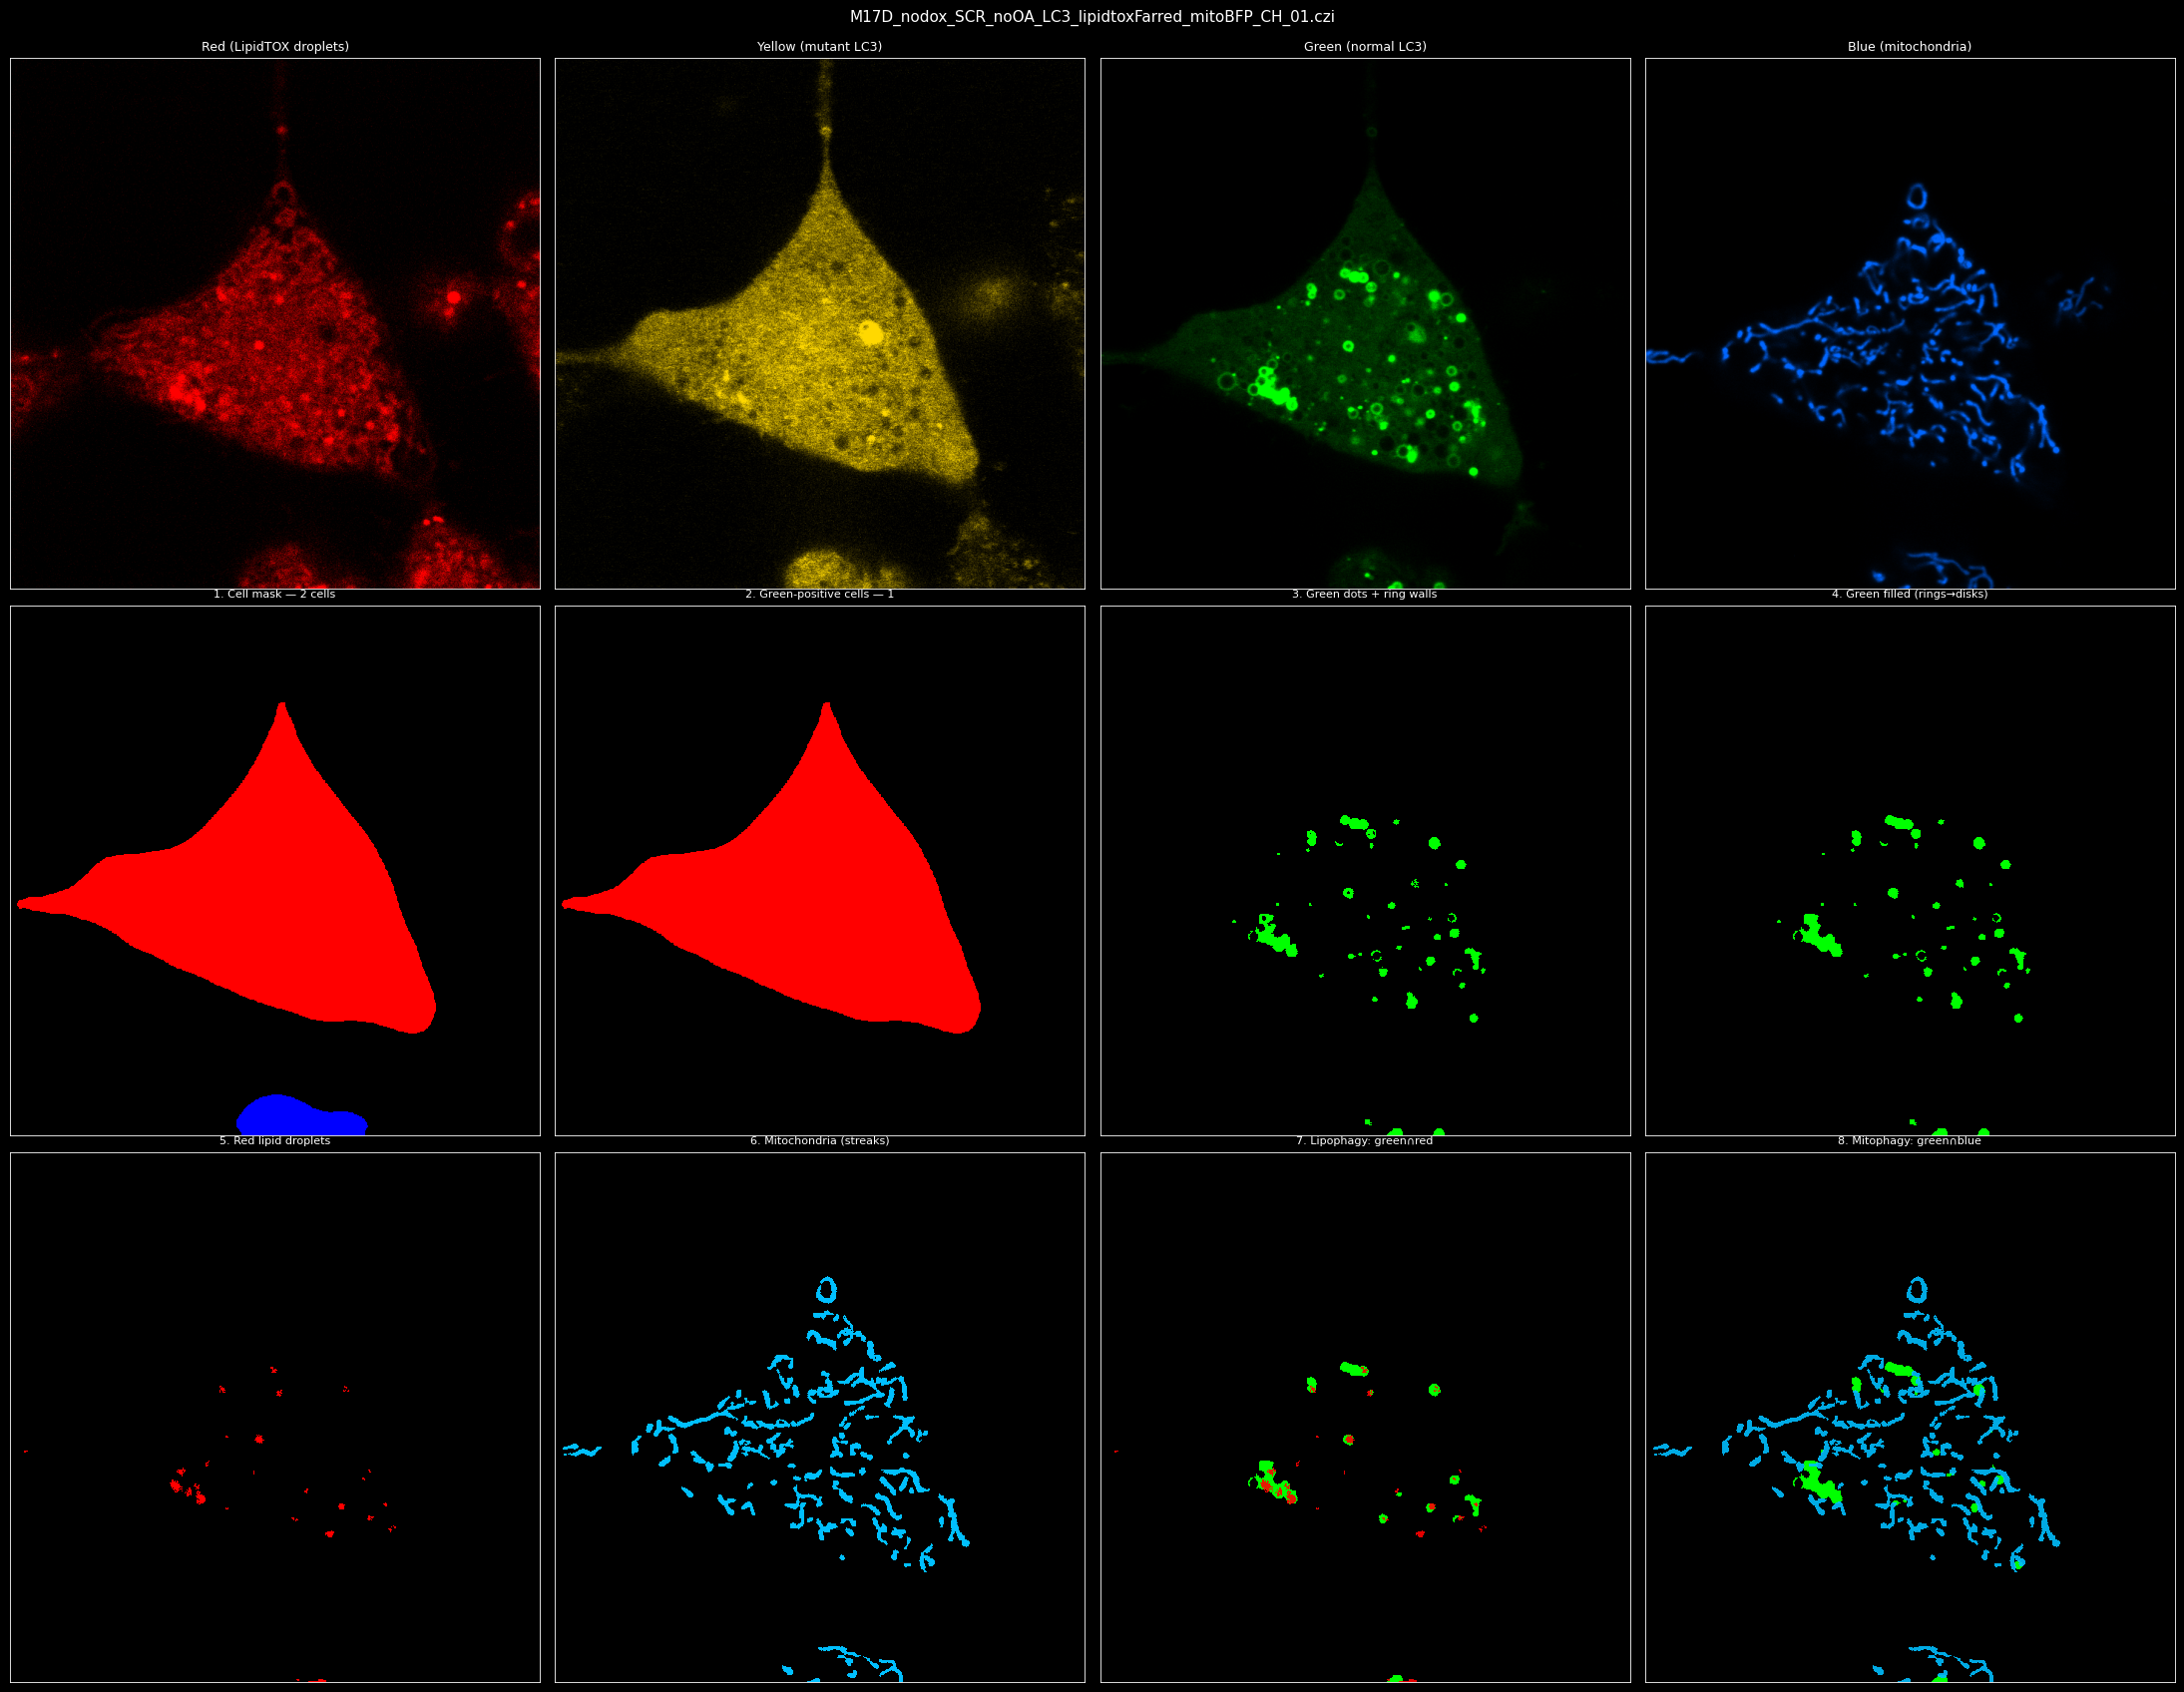


Processing: M17D_nodox_SCR_noOA_LC3_lipidtoxFarred_mitoBFP_noCH_06.czi
    Cells (cyto3 yellow+green, smoothed+signal-gated): 2
    Green-positive cells: 2 / 2 (fill >= 0.4)
    saved masks -> Results/masks/L3 Lipophagy images/M17D_nodox_SCR_noOA_LC3_lipidtoxFarred_mitoBFP_noCH_06


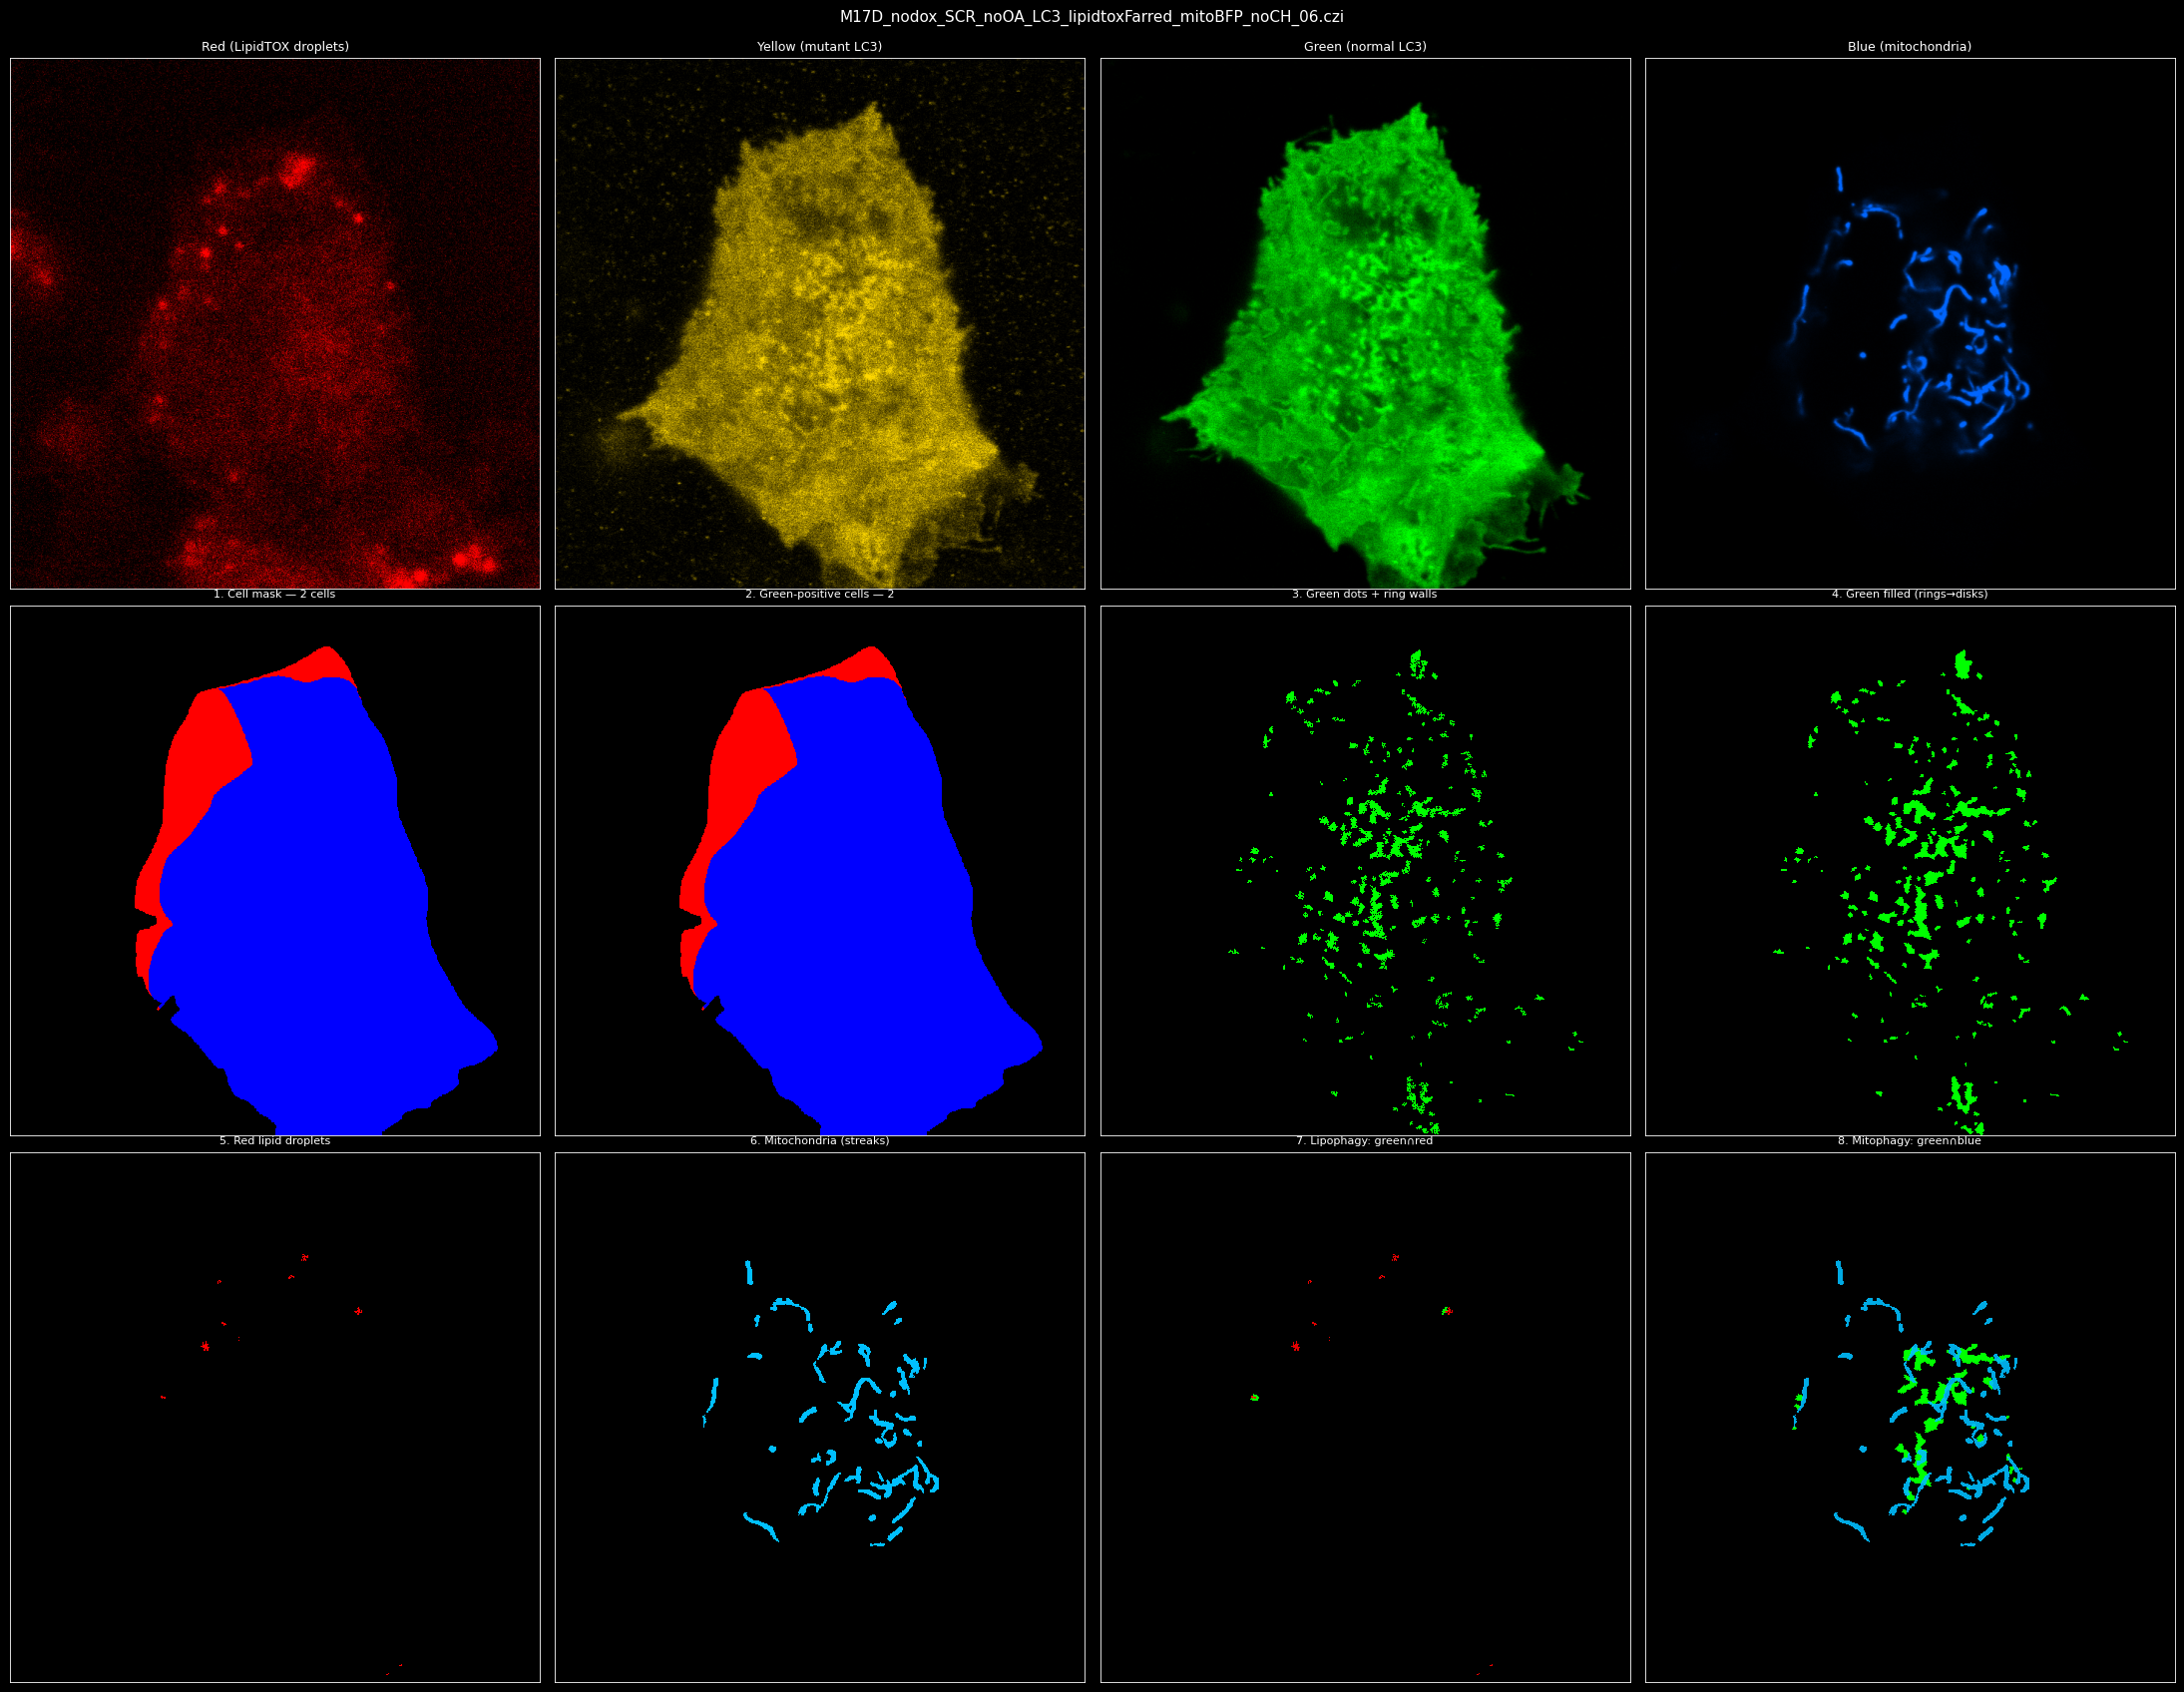

  -> 3 green-positive cell row(s) saved to Results/L3 Lipophagy images_LC3_lipophagy_mitophagy_analysis.csv

All folders processed — one CSV each in Results/, masks in Results/masks/<folder>/<image>/.


,Filename,Cell_ID,Cell_Area_px,N_Green_Dots_Circles_Per_Cell,N_Green_Structures,Green_Dots_Circles_Area_px,Green_Structure_Area_px,N_Lipid_Droplets,LipidDroplet_Area_px,Mito_Area_px,N_GreenRed_Coloc_Lipophagy,GreenRed_Overlap_Area_px,N_GreenBlue_Coloc_Mitophagy,GreenBlue_Overlap_Area_px,Green_MFI_raw,Yellow_MFI_raw,Red_MFI_raw
0,M17D_nodox_SCR_noOA_LC3_lipidtoxFarred_mitoBFP...,1,108078,41,41,4811,4811,26,1014,17153,12,750,18,463,2959.105,2528.710,1641.975
1,M17D_nodox_SCR_noOA_LC3_lipidtoxFarred_mitoBFP...,1,23764,21,21,1367,1367,4,118,908,1,14,3,12,4645.271,2277.019,475.932
2,M17D_nodox_SCR_noOA_LC3_lipidtoxFarred_mitoBFP...,2,184240,178,178,13529,13529,6,125,7257,1,3,24,987,5150.437,2664.493,532.364


In [10]:
def analyze_folder(image_folder):
    """Segment + analyze every image in one folder. Masks are saved per image to
    Results/masks/<folder>/<image>/, and one CSV is written for the whole folder."""
    folder_tag = os.path.basename(os.path.normpath(image_folder))
    mask_dir = os.path.join(MASK_FOLDER, folder_tag)
    os.makedirs(mask_dir, exist_ok=True)

    image_files = sorted(glob.glob(os.path.join(image_folder, FILE_EXTENSION)))
    print(f"{folder_tag}: {len(image_files)} image(s)")

    rows = []
    for filepath in image_files:
        result = segment_one_image(filepath, mask_dir)
        if result is None:
            continue
        for cid in result["green_positive_ids"]:
            row = analyze_cell(cid, result["labeled_cells"], result["masks"], result["raw"])
            row["Filename"] = os.path.basename(filepath)
            rows.append(row)

    if rows:
        df = pd.DataFrame(rows)
        front = ["Filename", "Cell_ID"]
        df = df[front + [c for c in df.columns if c not in front]]
    else:
        df = pd.DataFrame()

    out_csv = os.path.join(RESULTS_FOLDER, f"{folder_tag}_{CSV_SUFFIX}")
    df.to_csv(out_csv, index=False)
    print(f"  -> {len(df)} green-positive cell row(s) saved to {out_csv}\n")
    return df


last_df = None
for image_folder in IMAGE_FOLDERS:
    folder_tag = os.path.basename(os.path.normpath(image_folder))
    if not os.path.isdir(image_folder):
        print(f"[skip] '{image_folder}' not found\n")
        continue
    print(f"{folder_tag}: START")
    last_df = analyze_folder(image_folder)

print("All folders processed — one CSV each in Results/, "
      "masks in Results/masks/<folder>/<image>/.")
last_df.head() if last_df is not None else None

## 9 · Output summary — list the per‑folder CSVs and where the per‑image masks were saved

In [11]:
csv_files = sorted(glob.glob(os.path.join(RESULTS_FOLDER, f"*_{CSV_SUFFIX}")))
print(f"{len(csv_files)} CSV file(s) in {RESULTS_FOLDER}/:")
total_rows = 0
for f in csv_files:
    n = len(pd.read_csv(f))
    total_rows += n
    print(f"  {os.path.basename(f):70s} {n:>4d} green-positive cell row(s)")
print(f"  {'TOTAL':70s} {total_rows:>4d}")

print(f"\nMasks (per image file) under {MASK_FOLDER}/<folder>/<image>/:")
print("  labeled_cells.npy, green_struct.npy, green_filled.npy,")
print("  red_lipid.npy, mito.npy, green_positive_ids.npy")  

1 CSV file(s) in Results/:
  L3 Lipophagy images_LC3_lipophagy_mitophagy_analysis.csv                  3 green-positive cell row(s)
  TOTAL                                                                     3

Masks (per image file) under Results/masks/<folder>/<image>/:
  labeled_cells.npy, green_struct.npy, green_filled.npy,
  red_lipid.npy, mito.npy, green_positive_ids.npy
